# Redes neuronales y aprendizaje profundo

## De una capa oculta a redes convolucionales

**Capítulo de notas de clase en Python**  
**Correspondencia con el libro:** secciones 10.1, 10.2, 10.3, 10.6 y 10.7 de *An Introduction to Statistical Learning with Applications in Python*.

Este notebook sigue el estilo de un capítulo aplicado: combina intuición, formulación matemática, visualizaciones, código reproducible, comparaciones de modelos y ejercicios. La redacción, los ejemplos y las figuras son propios; el contenido conceptual se apoya en el capítulo 10 del libro.

### Objetivos de aprendizaje

Al terminar el capítulo se espera que puedas:

- interpretar una neurona, una capa oculta y una red *feed-forward*;
- explicar por qué una función de activación no lineal es indispensable;
- construir y entrenar redes densas de una y varias capas;
- entender filtros, mapas de características, *pooling*, aumento de datos y transferencia de aprendizaje en CNN;
- decidir cuándo el aprendizaje profundo es una elección razonable y cuándo un modelo clásico puede ser preferible;
- describir descenso por gradiente, retropropagación, mini-lotes, épocas, regularización, *dropout*, parada temprana y ajuste de hiperparámetros.

> **Alcance.** Se omiten deliberadamente las secciones 10.4 y 10.5 del libro, dedicadas a clasificación de documentos y redes recurrentes.

### Contenido

1. [10.1 Redes neuronales de una capa](#101-redes-neuronales-de-una-capa)
2. [10.2 Redes neuronales multicapa](#102-redes-neuronales-multicapa)
3. [10.3 Redes neuronales convolucionales](#103-redes-neuronales-convolucionales)
4. [10.6 ¿Cuándo usar aprendizaje profundo?](#106-cuándo-usar-aprendizaje-profundo)
5. [10.7 Ajuste de una red neuronal](#107-ajuste-de-una-red-neuronal)
6. [Resumen y ejercicios](#resumen)

### Requisitos

El notebook usa `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `torch` y `torchvision`. En un entorno nuevo puede instalarse lo necesario con:

```python
%pip install numpy pandas matplotlib scikit-learn torch torchvision
```

Los ejemplos principales trabajan con el conjunto `digits` de `scikit-learn`, por lo que no requieren descargar datos externos.

In [1]:
from __future__ import annotations

import copy
import math
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.datasets import load_diabetes, load_digits, make_moons
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torch.nn.functional as F
from torchvision.transforms import RandomAffine

%matplotlib inline

warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: cpu
PyTorch: 2.10.0+cpu


## 10.1 Redes neuronales de una capa

Una red neuronal recibe un vector de predictores

$$
X=(X_1,\ldots,X_p)
$$

y construye nuevas variables llamadas **activaciones**. En una red con una capa oculta y $K$ unidades,

$$
A_k=h_k(X)=g\!\left(w_{k0}+\sum_{j=1}^{p}w_{kj}X_j\right),
\qquad k=1,\ldots,K.
$$

La salida para un problema de regresión puede escribirse como

$$
f(X)=\beta_0+\sum_{k=1}^{K}\beta_k A_k.
$$

La red es lineal en las activaciones $A_k$, pero estas son transformaciones no lineales aprendidas de las variables originales. Los coeficientes $w_{kj}$, $w_{k0}$, $\beta_k$ y $\beta_0$ se estiman a partir de los datos.

> **Idea clave:** una capa oculta puede verse como una fábrica de características. Cada unidad aprende una combinación lineal distinta y la pasa por una función no lineal.

### Funciones de activación

Dos activaciones centrales son:

$$
\operatorname{sigmoid}(z)=\frac{1}{1+e^{-z}},
\qquad
\operatorname{ReLU}(z)=\max(0,z).
$$

La sigmoide comprime la entrada al intervalo $(0,1)$. ReLU es lineal por tramos, barata de calcular y suele facilitar el entrenamiento de redes profundas. También es frecuente `tanh`, cuya salida pertenece a $(-1,1)$.

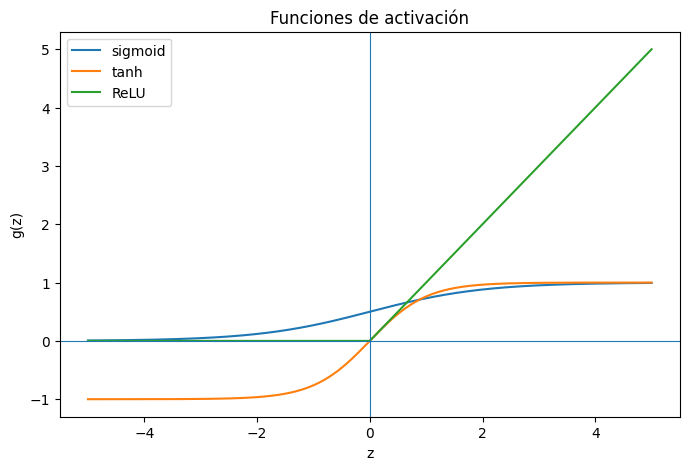

In [2]:
z = np.linspace(-5, 5, 500)
activaciones = {
    "sigmoid": 1 / (1 + np.exp(-z)),
    "tanh": np.tanh(z),
    "ReLU": np.maximum(z, 0),
}

plt.figure(figsize=(8, 5))
for nombre, valores in activaciones.items():
    plt.plot(z, valores, label=nombre)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("z")
plt.ylabel("g(z)")
plt.title("Funciones de activación")
plt.legend()
plt.show()

### Por qué la no linealidad es esencial

Si $g(z)=z$, la composición de capas lineales sigue siendo lineal: varias matrices multiplicadas pueden reemplazarse por una sola matriz. La activación no lineal permite representar curvaturas e interacciones.

Un ejemplo algebraico particularmente instructivo usa dos unidades con $g(z)=z^2$:

$$
h_1(X)=(X_1+X_2)^2,
\qquad
h_2(X)=(X_1-X_2)^2.
$$

Entonces,

$$
\frac14 h_1(X)-\frac14 h_2(X)=X_1X_2.
$$

Por tanto, una combinación lineal de activaciones no lineales puede reconstruir una interacción entre predictores.

In [3]:
rng = np.random.default_rng(SEED)
X_interaccion = rng.normal(size=(8, 2))

h1 = (X_interaccion[:, 0] + X_interaccion[:, 1]) ** 2
h2 = (X_interaccion[:, 0] - X_interaccion[:, 1]) ** 2
red = 0.25 * h1 - 0.25 * h2
producto = X_interaccion[:, 0] * X_interaccion[:, 1]

verificacion = pd.DataFrame({
    "X1": X_interaccion[:, 0],
    "X2": X_interaccion[:, 1],
    "salida_red": red,
    "X1*X2": producto,
    "diferencia": red - producto,
})
verificacion.round(6)

,X1,X2,salida_red,X1*X2,diferencia
0,0.304717,-1.039984,-0.316901,-0.316901,-0.0
1,0.750451,0.940565,0.705848,0.705848,0.0
2,-1.951035,-1.302180,2.540598,2.540598,0.0
3,0.127840,-0.316243,-0.040429,-0.040429,-0.0
4,-0.016801,-0.853044,0.014332,0.014332,-0.0
5,0.879398,0.777792,0.683989,0.683989,0.0
6,0.066031,1.127241,0.074433,0.074433,0.0
7,0.467509,-0.859292,-0.401727,-0.401727,0.0


### Ejemplo: una frontera no lineal con una sola capa oculta

El conjunto `make_moons` no puede separarse bien mediante una frontera lineal. Comparamos:

- regresión logística, cuya frontera es lineal en las variables escaladas;
- una red con **una capa oculta de 16 unidades ReLU**.

Este ejemplo reproduce la lógica pedagógica de las notas de clase: primero se observa el problema, luego se cambia la capacidad de la arquitectura y finalmente se evalúa fuera de muestra.

In [4]:
X_moons, y_moons = make_moons(
    n_samples=800,
    noise=0.25,
    random_state=SEED,
)

X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.30,
    stratify=y_moons,
    random_state=SEED,
)

modelo_lineal = make_pipeline(
    StandardScaler(),
    LogisticRegression(),
)

modelo_una_capa = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="lbfgs",
        alpha=0.001,
        max_iter=3000,
        random_state=SEED,
    ),
)

modelo_lineal.fit(X_m_train, y_m_train)
modelo_una_capa.fit(X_m_train, y_m_train)

resultados_moons = pd.DataFrame([
    {
        "Modelo": "Regresión logística",
        "Exactitud entrenamiento": accuracy_score(y_m_train, modelo_lineal.predict(X_m_train)),
        "Exactitud prueba": accuracy_score(y_m_test, modelo_lineal.predict(X_m_test)),
    },
    {
        "Modelo": "Red: una capa oculta (16)",
        "Exactitud entrenamiento": accuracy_score(y_m_train, modelo_una_capa.predict(X_m_train)),
        "Exactitud prueba": accuracy_score(y_m_test, modelo_una_capa.predict(X_m_test)),
    },
])
resultados_moons.round(3)

,Modelo,Exactitud entrenamiento,Exactitud prueba
0,Regresión logística,0.861,0.892
1,Red: una capa oculta (16),0.946,0.967


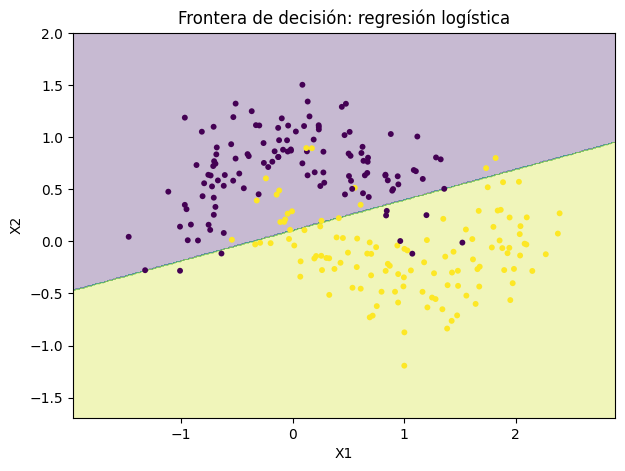

In [5]:
def graficar_frontera(modelo, X, y, titulo):
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 350),
        np.linspace(x2_min, x2_max, 350),
    )
    malla = np.c_[xx.ravel(), yy.ravel()]
    zz = modelo.predict(malla).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, zz, alpha=0.30)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolors="none")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(titulo)
    plt.show()


graficar_frontera(
    modelo_lineal,
    X_m_test,
    y_m_test,
    "Frontera de decisión: regresión logística",
)

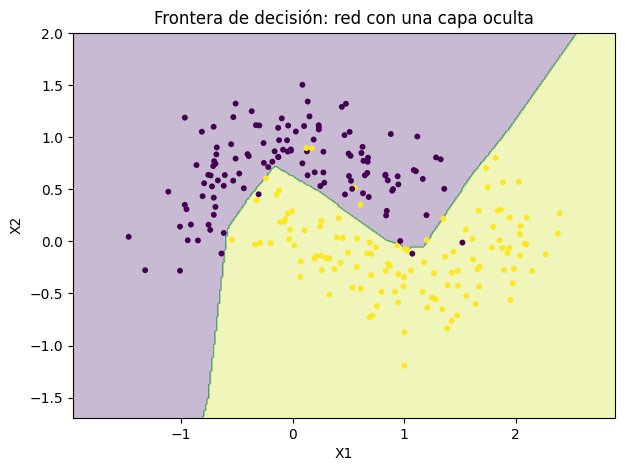

In [6]:
graficar_frontera(
    modelo_una_capa,
    X_m_test,
    y_m_test,
    "Frontera de decisión: red con una capa oculta",
)

### Lectura del ejemplo

La red no recibe explícitamente términos como $X_1^2$, $X_2^2$ o $X_1X_2$. Aprende transformaciones internas que producen una frontera curva. El número de unidades controla parte de la flexibilidad: muy pocas pueden subajustar; demasiadas, sin regularización, pueden sobreajustar.

## 10.2 Redes neuronales multicapa

Una red profunda aplica transformaciones sucesivas. Si $A^{(0)}=X$, una forma compacta de escribir una red densa es

$$
A^{(\ell)}=g\!\left(W^{(\ell)}A^{(\ell-1)}+b^{(\ell)}\right),
\qquad \ell=1,\ldots,L.
$$

Cada capa trabaja sobre las características construidas por la capa anterior. La profundidad permite formar representaciones jerárquicas: patrones simples en capas tempranas y combinaciones más abstractas en capas posteriores.

Para clasificación multiclase, la capa final genera *logits* $Z_m$. La función *softmax* los convierte en probabilidades:

$$
\Pr(Y=m\mid X)=\frac{e^{Z_m}}{\sum_{r=1}^{M}e^{Z_r}}.
$$

La pérdida habitual es la **entropía cruzada**:

$$
-\sum_{i=1}^{n}\sum_{m=1}^{M}y_{im}\log \hat p_{im}.
$$

En PyTorch, `CrossEntropyLoss` recibe directamente los logits; aplica internamente una versión numéricamente estable de `log_softmax` y la pérdida negativa logarítmica.

### Datos: dígitos manuscritos

El libro ilustra las redes multicapa con MNIST. Para que este capítulo sea totalmente ejecutable sin descargas, utilizamos `load_digits`:

- 1 797 imágenes;
- 10 clases, de 0 a 9;
- imágenes de $8\times8$ píxeles;
- intensidades entre 0 y 16, reescaladas al intervalo $[0,1]$.

In [7]:
digits = load_digits()
X_digits = digits.images.astype(np.float32) / 16.0
y_digits = digits.target.astype(np.int64)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_digits,
    y_digits,
    test_size=0.20,
    stratify=y_digits,
    random_state=SEED,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    stratify=y_train_val,
    random_state=SEED,
)

pd.Series({
    "Entrenamiento": len(X_train),
    "Validación": len(X_val),
    "Prueba": len(X_test),
    "Clases": len(np.unique(y_digits)),
    "Píxeles por imagen": X_digits.shape[1] * X_digits.shape[2],
})

Entrenamiento         1149
Validación             288
Prueba                 360
Clases                  10
Píxeles por imagen      64
dtype: int64

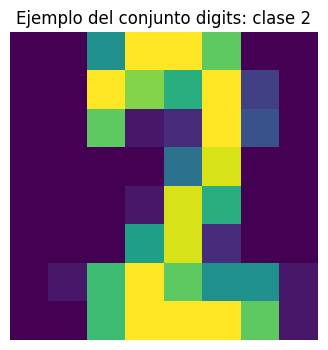

In [8]:
plt.figure(figsize=(4, 4))
plt.imshow(X_train[0])
plt.title(f"Ejemplo del conjunto digits: clase {y_train[0]}")
plt.axis("off")
plt.show()

### Utilidades de entrenamiento

Las funciones siguientes implementan el ciclo básico que repetiremos:

1. pasada hacia adelante;
2. cálculo de la pérdida;
3. `backward()` para obtener gradientes;
4. actualización de parámetros mediante el optimizador;
5. evaluación en validación;
6. parada temprana y restauración del mejor estado.

In [9]:
def contar_parametros(modelo: nn.Module, solo_entrenables: bool = False) -> int:
    parametros = modelo.parameters()
    if solo_entrenables:
        parametros = (p for p in parametros if p.requires_grad)
    return sum(p.numel() for p in parametros)


def crear_loaders(
    X_tr,
    y_tr,
    X_va,
    y_va,
    X_te,
    y_te,
    batch_size: int = 64,
):
    def dataset(X, y):
        return TensorDataset(
            torch.as_tensor(X, dtype=torch.float32),
            torch.as_tensor(y, dtype=torch.long),
        )

    generador = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(
        dataset(X_tr, y_tr),
        batch_size=batch_size,
        shuffle=True,
        generator=generador,
    )
    val_loader = DataLoader(dataset(X_va, y_va), batch_size=256)
    test_loader = DataLoader(dataset(X_te, y_te), batch_size=256)
    return train_loader, val_loader, test_loader


def evaluar_clasificador(modelo: nn.Module, loader: DataLoader):
    modelo.eval()
    criterio = nn.CrossEntropyLoss(reduction="sum")
    perdida_total = 0.0
    aciertos = 0
    n = 0
    predicciones = []
    verdaderos = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = modelo(xb)
            perdida_total += criterio(logits, yb).item()
            pred = logits.argmax(dim=1)
            aciertos += (pred == yb).sum().item()
            n += len(yb)
            predicciones.append(pred.cpu())
            verdaderos.append(yb.cpu())

    return {
        "loss": perdida_total / n,
        "accuracy": aciertos / n,
        "y_pred": torch.cat(predicciones).numpy(),
        "y_true": torch.cat(verdaderos).numpy(),
    }


def entrenar_clasificador(
    modelo: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_epochs: int = 30,
    learning_rate: float = 1e-3,
    weight_decay: float = 0.0,
    patience: int | None = 6,
    restaurar_mejor: bool = True,
):
    modelo.to(DEVICE)
    criterio = nn.CrossEntropyLoss()
    optimizador = torch.optim.Adam(
        (p for p in modelo.parameters() if p.requires_grad),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    mejor_loss = math.inf
    mejor_estado = None
    espera = 0
    historia = []

    for epoch in range(1, max_epochs + 1):
        modelo.train()
        perdida_acum = 0.0
        aciertos = 0
        n = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizador.zero_grad()
            logits = modelo(xb)
            perdida = criterio(logits, yb)
            perdida.backward()
            optimizador.step()

            perdida_acum += perdida.item() * len(yb)
            aciertos += (logits.argmax(dim=1) == yb).sum().item()
            n += len(yb)

        validacion = evaluar_clasificador(modelo, val_loader)
        historia.append({
            "epoch": epoch,
            "train_loss": perdida_acum / n,
            "train_accuracy": aciertos / n,
            "val_loss": validacion["loss"],
            "val_accuracy": validacion["accuracy"],
        })

        if validacion["loss"] < mejor_loss - 1e-5:
            mejor_loss = validacion["loss"]
            mejor_estado = copy.deepcopy(modelo.state_dict())
            espera = 0
        else:
            espera += 1

        if patience is not None and espera >= patience:
            break

    if restaurar_mejor and mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)

    return pd.DataFrame(historia)


train_loader, val_loader, test_loader = crear_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)

In [10]:
class ClasificadorDenso(nn.Module):
    def __init__(
        self,
        input_size: int = 64,
        hidden_sizes: tuple[int, ...] = (128, 64),
        dropout: float = 0.20,
        n_classes: int = 10,
    ):
        super().__init__()
        capas = [nn.Flatten()]
        anterior = input_size
        for unidades in hidden_sizes:
            capas.extend([
                nn.Linear(anterior, unidades),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            anterior = unidades
        capas.append(nn.Linear(anterior, n_classes))
        self.net = nn.Sequential(*capas)

    def forward(self, x):
        return self.net(x)


torch.manual_seed(SEED)
modelo_denso = ClasificadorDenso(hidden_sizes=(128, 64), dropout=0.20)
print(modelo_denso)
print(f"Parámetros entrenables: {contar_parametros(modelo_denso):,}")

ClasificadorDenso(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)
Parámetros entrenables: 17,226


In [11]:
inicio = time.perf_counter()
historia_densa = entrenar_clasificador(
    modelo_denso,
    train_loader,
    val_loader,
    max_epochs=35,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=7,
)
tiempo_denso = time.perf_counter() - inicio

eval_densa = evaluar_clasificador(modelo_denso, test_loader)

pd.Series({
    "Épocas ejecutadas": len(historia_densa),
    "Exactitud de prueba": eval_densa["accuracy"],
    "Entropía cruzada de prueba": eval_densa["loss"],
    "Tiempo (s)": tiempo_denso,
}).round(4)

Épocas ejecutadas             35.0000
Exactitud de prueba            0.9722
Entropía cruzada de prueba     0.0924
Tiempo (s)                     0.8199
dtype: float64

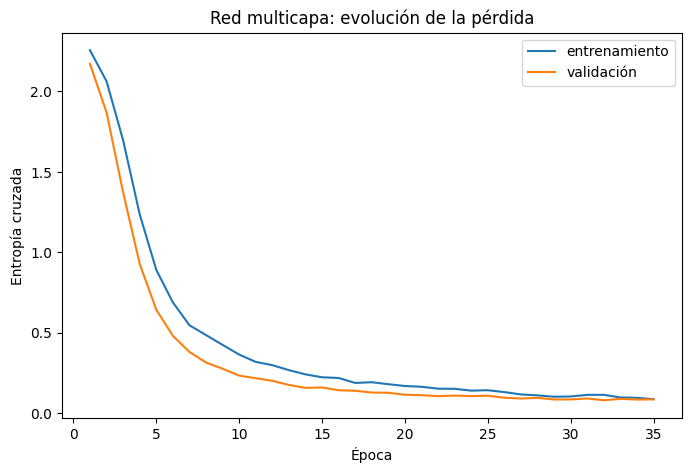

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(historia_densa["epoch"], historia_densa["train_loss"], label="entrenamiento")
plt.plot(historia_densa["epoch"], historia_densa["val_loss"], label="validación")
plt.xlabel("Época")
plt.ylabel("Entropía cruzada")
plt.title("Red multicapa: evolución de la pérdida")
plt.legend()
plt.show()

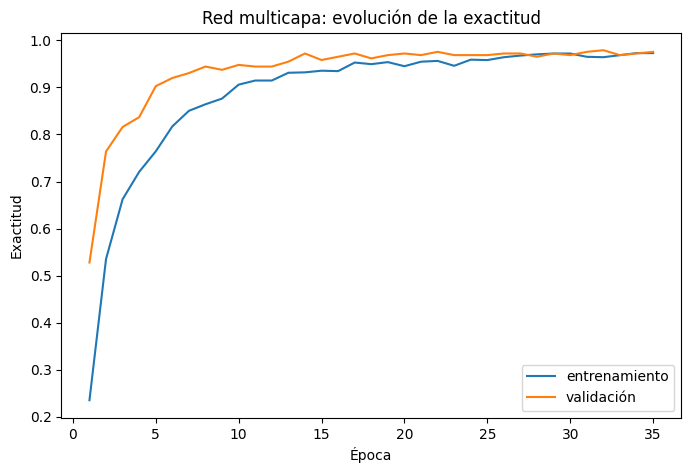

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(historia_densa["epoch"], historia_densa["train_accuracy"], label="entrenamiento")
plt.plot(historia_densa["epoch"], historia_densa["val_accuracy"], label="validación")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.title("Red multicapa: evolución de la exactitud")
plt.legend()
plt.show()

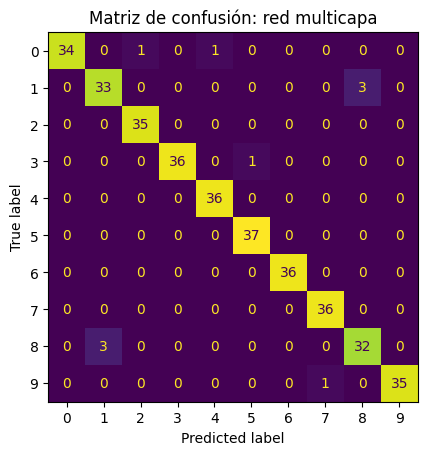

In [14]:
ConfusionMatrixDisplay.from_predictions(
    eval_densa["y_true"],
    eval_densa["y_pred"],
    colorbar=False,
)
plt.title("Matriz de confusión: red multicapa")
plt.show()

### Interpretación

La red anterior transforma 64 píxeles en 128 activaciones, luego en 64 y finalmente en 10 logits. La salida no necesita una capa `Softmax` explícita durante el entrenamiento porque la pérdida ya la incorpora. Para obtener probabilidades después del ajuste se puede aplicar:

```python
probabilidades = torch.softmax(logits, dim=1)
```

La separación entrenamiento-validación permite vigilar el sobreajuste. Cuando la pérdida de validación deja de mejorar, continuar reduciendo la pérdida de entrenamiento puede perjudicar la generalización.

## 10.3 Redes neuronales convolucionales

Las redes densas ignoran la geometría de una imagen: al aplanar una matriz, dos píxeles vecinos dejan de tener un tratamiento especial. Una CNN conserva la estructura espacial mediante:

- **conectividad local:** cada filtro observa una ventana pequeña;
- **pesos compartidos:** el mismo filtro se aplica en todas las posiciones;
- **mapas de características:** cada filtro produce una nueva representación espacial;
- **jerarquía:** filtros tempranos detectan bordes o texturas y capas posteriores combinan esos patrones.

Para una entrada de tamaño $H$, filtro de tamaño $K$, relleno $P$ y paso $S$, el tamaño de salida en una dimensión es

$$
H_{\text{out}}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1.
$$

### 10.3.1 Capas de convolución

Los marcos de aprendizaje profundo suelen implementar correlación cruzada y la denominan convolución: el filtro se desplaza, multiplica elemento a elemento y suma. Los valores del filtro se aprenden durante el entrenamiento.

A continuación aplicamos un filtro tipo Sobel a un dígito. El ejemplo permite ver cómo una plantilla pequeña resalta cambios locales de intensidad.

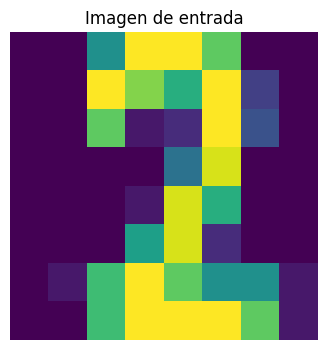

In [15]:
imagen = torch.tensor(X_train[0], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
filtro_vertical = torch.tensor(
    [[[-1.0, 0.0, 1.0],
      [-2.0, 0.0, 2.0],
      [-1.0, 0.0, 1.0]]],
    dtype=torch.float32,
).unsqueeze(0)

respuesta = F.conv2d(imagen, filtro_vertical, padding=1)

plt.figure(figsize=(4, 4))
plt.imshow(imagen.squeeze().numpy())
plt.title("Imagen de entrada")
plt.axis("off")
plt.show()

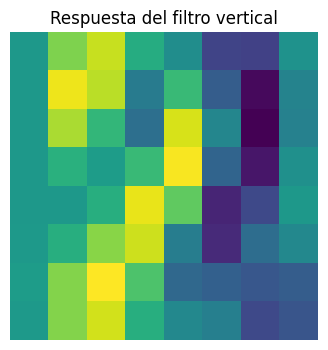

In [16]:
plt.figure(figsize=(4, 4))
plt.imshow(respuesta.squeeze().numpy())
plt.title("Respuesta del filtro vertical")
plt.axis("off")
plt.show()

### 10.3.2 Capas de *pooling*

El *max pooling* toma el máximo dentro de pequeñas ventanas. Un bloque $2\times2$ con paso 2 reduce a la mitad cada dimensión espacial. La operación:

- disminuye el costo de las capas posteriores;
- resume la presencia de una característica;
- aporta cierta tolerancia a pequeños desplazamientos.

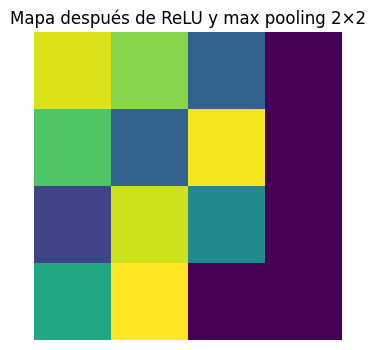

Forma original: (1, 1, 8, 8)
Forma tras convolución: (1, 1, 8, 8)
Forma tras pooling: (1, 1, 4, 4)


In [17]:
pooled = F.max_pool2d(torch.relu(respuesta), kernel_size=2, stride=2)

plt.figure(figsize=(4, 4))
plt.imshow(pooled.squeeze().numpy())
plt.title("Mapa después de ReLU y max pooling 2×2")
plt.axis("off")
plt.show()

print("Forma original:", tuple(imagen.shape))
print("Forma tras convolución:", tuple(respuesta.shape))
print("Forma tras pooling:", tuple(pooled.shape))

### 10.3.3 Arquitectura de una CNN

Una arquitectura típica alterna bloques de convolución, activación y *pooling*. Al reducirse las dimensiones espaciales suele aumentarse el número de canales. Finalmente, los mapas se aplanan y alimentan una o más capas densas antes de la salida.

La CNN siguiente utiliza:

1. convolución $1\to16$, ReLU y *pooling*;
2. convolución $16\to32$, ReLU y *pooling*;
3. capa densa de 64 unidades;
4. `dropout` y salida de 10 logits.

In [18]:
class CNNPequena(nn.Module):
    def __init__(self, dropout: float = 0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(32 * 2 * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)
        z = self.features(x)
        return self.classifier(z)


torch.manual_seed(SEED)
modelo_cnn = CNNPequena(dropout=0.25)
print(modelo_cnn)
print(f"Parámetros entrenables: {contar_parametros(modelo_cnn):,}")

CNNPequena(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.25, inplace=False)
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
Parámetros entrenables: 13,706


In [19]:
inicio = time.perf_counter()
historia_cnn = entrenar_clasificador(
    modelo_cnn,
    train_loader,
    val_loader,
    max_epochs=35,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=7,
)
tiempo_cnn = time.perf_counter() - inicio

eval_cnn = evaluar_clasificador(modelo_cnn, test_loader)

comparacion_imagenes = pd.DataFrame([
    {
        "Modelo": "Red densa 128-64",
        "Parámetros": contar_parametros(modelo_denso),
        "Exactitud prueba": eval_densa["accuracy"],
        "Pérdida prueba": eval_densa["loss"],
        "Tiempo (s)": tiempo_denso,
    },
    {
        "Modelo": "CNN 16-32",
        "Parámetros": contar_parametros(modelo_cnn),
        "Exactitud prueba": eval_cnn["accuracy"],
        "Pérdida prueba": eval_cnn["loss"],
        "Tiempo (s)": tiempo_cnn,
    },
])
comparacion_imagenes.round(4)

,Modelo,Parámetros,Exactitud prueba,Pérdida prueba,Tiempo (s)
0,Red densa 128-64,17226,0.9722,0.0924,0.8199
1,CNN 16-32,13706,0.9778,0.0872,1.5074


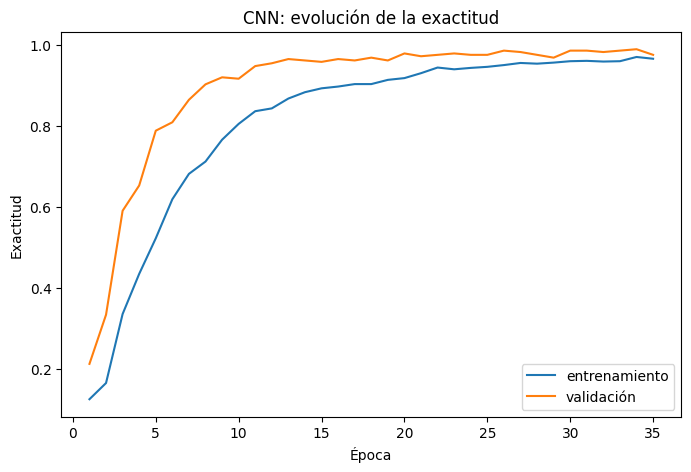

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(historia_cnn["epoch"], historia_cnn["train_accuracy"], label="entrenamiento")
plt.plot(historia_cnn["epoch"], historia_cnn["val_accuracy"], label="validación")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.title("CNN: evolución de la exactitud")
plt.legend()
plt.show()

### 10.3.4 Aumento de datos

El aumento de datos genera versiones plausibles de cada observación: pequeños giros, traslaciones, cambios de escala o reflejos. La etiqueta se conserva. En vez de almacenar todas las copias, las transformaciones pueden aplicarse **al vuelo** cuando se forma cada mini-lote.

El aumento actúa como regularización porque obliga a la red a aprender una representación estable ante perturbaciones que no cambian la clase.

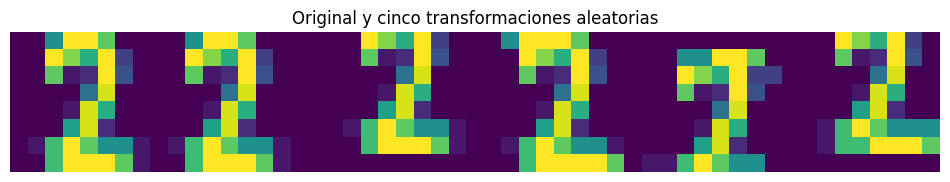

In [21]:
aumento = RandomAffine(
    degrees=10,
    translate=(0.08, 0.08),
    scale=(0.95, 1.05),
)

base = torch.tensor(X_train[0], dtype=torch.float32).unsqueeze(0)
versiones = [base.squeeze().numpy()]
for _ in range(5):
    versiones.append(aumento(base).squeeze().numpy())

separador = np.zeros((8, 1), dtype=np.float32)
tira = versiones[0]
for version in versiones[1:]:
    tira = np.concatenate([tira, separador, version], axis=1)

plt.figure(figsize=(12, 3))
plt.imshow(tira)
plt.title("Original y cinco transformaciones aleatorias")
plt.axis("off")
plt.show()

In [22]:
class DigitsAumentados(Dataset):
    """Dataset que aplica una transformación distinta cada vez que se consulta una imagen."""

    def __init__(self, X, y, transform=None):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].unsqueeze(0)
        if self.transform is not None:
            x = self.transform(x)
        return x, self.y[idx]


loader_aumentado = DataLoader(
    DigitsAumentados(X_train, y_train, transform=aumento),
    batch_size=64,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

xb_aug, yb_aug = next(iter(loader_aumentado))
print("Forma de un mini-lote aumentado:", tuple(xb_aug.shape))
print("Las transformaciones se generan de nuevo en cada recorrido del DataLoader.")

Forma de un mini-lote aumentado: (64, 1, 8, 8)
Las transformaciones se generan de nuevo en cada recorrido del DataLoader.


### 10.3.5 Clasificadores preentrenados y transferencia de aprendizaje

Entrenar una CNN grande desde cero puede requerir millones de imágenes. La transferencia de aprendizaje reutiliza capas convolucionales aprendidas en una tarea amplia y entrena solo una nueva cabeza de salida.

El procedimiento habitual es:

1. cargar una red preentrenada;
2. congelar total o parcialmente el extractor de características;
3. reemplazar la última capa para la nueva respuesta;
4. entrenar la cabeza y, si hay suficientes datos, descongelar algunas capas para un ajuste fino.

El siguiente ejemplo reutiliza el extractor de la CNN de dígitos para una nueva tarea: clasificar si un dígito es par o impar. Es una versión pequeña y completamente local del principio de *weight freezing*.

In [23]:
class ClasificadorParidadCongelado(nn.Module):
    def __init__(self, extractor_preentrenado: nn.Module):
        super().__init__()
        self.features = copy.deepcopy(extractor_preentrenado)
        for parametro in self.features.parameters():
            parametro.requires_grad_(False)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 2 * 2, 2),
        )

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)
        with torch.no_grad():
            z = self.features(x)
        return self.head(z)


y_train_paridad = y_train % 2
y_val_paridad = y_val % 2
y_test_paridad = y_test % 2

train_par, val_par, test_par = crear_loaders(
    X_train,
    y_train_paridad,
    X_val,
    y_val_paridad,
    X_test,
    y_test_paridad,
)

torch.manual_seed(SEED)
modelo_paridad = ClasificadorParidadCongelado(modelo_cnn.features)
historia_paridad = entrenar_clasificador(
    modelo_paridad,
    train_par,
    val_par,
    max_epochs=15,
    learning_rate=3e-3,
    patience=4,
)
eval_paridad = evaluar_clasificador(modelo_paridad, test_par)

pd.Series({
    "Parámetros totales": contar_parametros(modelo_paridad),
    "Parámetros entrenables": contar_parametros(modelo_paridad, solo_entrenables=True),
    "Exactitud de prueba (par/impar)": eval_paridad["accuracy"],
    "Épocas": len(historia_paridad),
}).round(4)

Parámetros totales                 5058.0000
Parámetros entrenables              258.0000
Exactitud de prueba (par/impar)       0.9639
Épocas                               15.0000
dtype: float64

#### Demostración opcional con ImageNet

La celda siguiente queda desactivada para mantener el notebook reproducible sin internet. Al cambiar `EJECUTAR_IMAGENET = True`, descarga los pesos de ResNet-18 y clasifica una imagen incluida en `scikit-image`.

In [24]:
EJECUTAR_IMAGENET = False

if EJECUTAR_IMAGENET:
    from PIL import Image
    from skimage import data
    from torchvision.models import ResNet18_Weights, resnet18

    pesos = ResNet18_Weights.DEFAULT
    resnet = resnet18(weights=pesos).eval()
    preprocesamiento = pesos.transforms()

    imagen_rgb = Image.fromarray(data.astronaut())
    lote = preprocesamiento(imagen_rgb).unsqueeze(0)

    with torch.no_grad():
        probabilidades = torch.softmax(resnet(lote), dim=1)[0]

    valores, indices = probabilidades.topk(5)
    categorias = pesos.meta["categories"]
    display(pd.DataFrame({
        "clase": [categorias[i] for i in indices.tolist()],
        "probabilidad": valores.tolist(),
    }))
else:
    print("Demostración ImageNet omitida. Cambia EJECUTAR_IMAGENET a True para ejecutarla.")

Demostración ImageNet omitida. Cambia EJECUTAR_IMAGENET a True para ejecutarla.


## 10.6 ¿Cuándo usar aprendizaje profundo?

El aprendizaje profundo no sustituye automáticamente a los métodos clásicos. En el ejemplo `Hitters` del libro, una regresión lineal, el lasso y una red con 1 345 parámetros obtienen desempeños de prueba similares. La red exige más decisiones de arquitectura y regularización, mientras que los modelos lineales se ajustan con mayor facilidad y son interpretables.

| Modelo en `Hitters` | Parámetros | MAE de prueba | $R^2$ de prueba |
|---|---:|---:|---:|
| Regresión lineal | 20 | 254.7 | 0.56 |
| Lasso | 12 | 252.3 | 0.51 |
| Red neuronal | 1 345 | 257.4 | 0.54 |

**El aprendizaje profundo suele ser atractivo cuando:**

- hay un conjunto de entrenamiento muy grande;
- las entradas tienen estructura compleja: imágenes, audio, texto, vídeo o secuencias;
- la tarea se beneficia de aprender representaciones automáticamente;
- la prioridad es la precisión predictiva y no la interpretación detallada;
- existe capacidad de cómputo y tiempo para experimentar.

**Un método clásico suele ser una primera opción sólida cuando:**

- los datos son tabulares y el tamaño muestral es pequeño o mediano;
- importa cuantificar efectos, incertidumbre o significancia;
- existe una relación relativamente simple;
- el costo de ajuste y mantenimiento debe ser bajo.

### Experimento tabular: modelos clásicos frente a una red

Usamos el conjunto `diabetes`, con 442 observaciones y 10 predictores. Se comparan regresión lineal, ridge, lasso y una red de una capa oculta mediante validación cruzada de cinco particiones.

Este experimento no pretende declarar un ganador universal. Ilustra que, con pocos datos tabulares, una red puede ser competitiva sin ofrecer una ventaja clara y con un costo de ajuste mayor.

In [25]:
X_diabetes, y_diabetes = load_diabetes(return_X_y=True)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

modelos_tabulares = {
    "Lineal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 40)),
    ),
    "Lasso": make_pipeline(
        StandardScaler(),
        LassoCV(
            alphas=np.logspace(-4, 2, 50),
            max_iter=20_000,
            random_state=SEED,
        ),
    ),
    "Red 10-64-1": TransformedTargetRegressor(
        regressor=make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=(64,),
                activation="relu",
                alpha=0.1,
                early_stopping=True,
                max_iter=1_000,
                random_state=SEED,
            ),
        ),
        transformer=StandardScaler(),
    ),
}

filas = []
for nombre, modelo in modelos_tabulares.items():
    resultado = cross_validate(
        modelo,
        X_diabetes,
        y_diabetes,
        cv=cv,
        scoring={"MAE": "neg_mean_absolute_error", "R2": "r2"},
    )
    filas.append({
        "Modelo": nombre,
        "MAE CV": -resultado["test_MAE"].mean(),
        "R2 CV": resultado["test_R2"].mean(),
        "Tiempo de ajuste medio (s)": resultado["fit_time"].mean(),
    })

resultados_tabulares = pd.DataFrame(filas).sort_values("MAE CV")
resultados_tabulares.round(4)

,Modelo,MAE CV,R2 CV,Tiempo de ajuste medio (s)
0,Lineal,44.2697,0.4785,0.0009
1,Ridge,44.3909,0.4777,0.0027
2,Lasso,44.6150,0.4740,0.0182
3,Red 10-64-1,44.7432,0.4597,0.0359


In [26]:
# Conteo orientativo de parámetros para dimensionar la diferencia de complejidad.
parametros_aproximados = pd.DataFrame({
    "Modelo": ["Lineal", "Ridge", "Lasso", "Red 10-64-1"],
    "Parámetros aproximados": [11, 11, "≤ 11", (10 + 1) * 64 + (64 + 1) * 1],
})
parametros_aproximados

,Modelo,Parámetros aproximados
0,Lineal,11
1,Ridge,11
2,Lasso,≤ 11
3,Red 10-64-1,769


### Regla práctica

Antes de usar una red, construye una línea base sencilla y mide el beneficio incremental. En datos tabulares, una mejora pequeña puede no justificar la pérdida de interpretabilidad, la sensibilidad a hiperparámetros ni el costo operativo. En imágenes o texto a gran escala, la capacidad de aprender representaciones suele cambiar por completo el balance.

## 10.7 Ajuste de una red neuronal

Para regresión, una red puede estimarse minimizando

$$
R(\theta)=\frac12\sum_{i=1}^{n}\left(y_i-f_\theta(x_i)\right)^2,
$$

donde $\theta$ reúne todos los pesos y sesgos. En clasificación se reemplaza el error cuadrático por entropía cruzada.

El objetivo es generalmente **no convexo**: puede haber varios mínimos locales, regiones planas y puntos silla. Por ello, la inicialización y el recorrido del optimizador influyen en el resultado.

### Descenso por gradiente

El gradiente $\nabla R(\theta_t)$ apunta en la dirección de mayor incremento local. Para reducir la función objetivo se avanza en la dirección opuesta:

$$
\theta_{t+1}=\theta_t-\rho\nabla R(\theta_t),
$$

donde $\rho>0$ es la **tasa de aprendizaje**.

- Si $\rho$ es demasiado grande, el algoritmo puede oscilar o divergir.
- Si $\rho$ es demasiado pequeño, el entrenamiento puede ser innecesariamente lento.

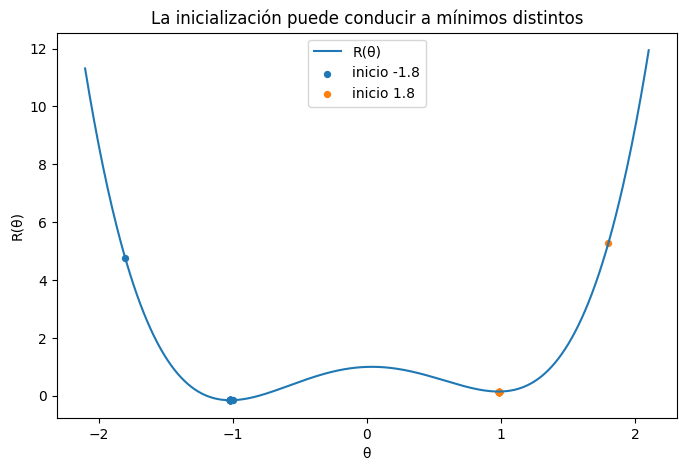

In [27]:
def objetivo_no_convexo(theta):
    return (theta**2 - 1) ** 2 + 0.15 * theta


def gradiente_no_convexo(theta):
    return 4 * theta * (theta**2 - 1) + 0.15


def descenso_1d(inicio, lr=0.05, pasos=35):
    theta = float(inicio)
    ruta = [theta]
    for _ in range(pasos):
        theta -= lr * gradiente_no_convexo(theta)
        ruta.append(theta)
    return np.array(ruta)


ruta_izquierda = descenso_1d(-1.8)
ruta_derecha = descenso_1d(1.8)
eje = np.linspace(-2.1, 2.1, 500)

plt.figure(figsize=(8, 5))
plt.plot(eje, objetivo_no_convexo(eje), label="R(θ)")
plt.scatter(ruta_izquierda, objetivo_no_convexo(ruta_izquierda), s=18, label="inicio -1.8")
plt.scatter(ruta_derecha, objetivo_no_convexo(ruta_derecha), s=18, label="inicio 1.8")
plt.xlabel("θ")
plt.ylabel("R(θ)")
plt.title("La inicialización puede conducir a mínimos distintos")
plt.legend()
plt.show()

### 10.7.1 Retropropagación

La retropropagación no es un optimizador; es un procedimiento eficiente para calcular derivadas mediante la regla de la cadena.

En una red simple, el error de salida se distribuye hacia atrás:

1. se deriva la pérdida respecto de la salida;
2. esa derivada se multiplica por la derivada de la activación;
3. el proceso continúa capa por capa;
4. cada peso recibe un gradiente que cuantifica su contribución local al error.

Las bibliotecas modernas construyen un grafo de operaciones durante la pasada hacia adelante y aplican diferenciación automática en `backward()`.

In [28]:
# Comprobación de un gradiente con autograd y diferencias finitas.
x = torch.tensor([0.6, -1.2], dtype=torch.float64)
y_objetivo = torch.tensor(0.7, dtype=torch.float64)

w = torch.tensor([0.4, -0.3], dtype=torch.float64, requires_grad=True)
b = torch.tensor(0.1, dtype=torch.float64, requires_grad=True)
v = torch.tensor(1.1, dtype=torch.float64, requires_grad=True)
c = torch.tensor(-0.2, dtype=torch.float64, requires_grad=True)

z = torch.dot(w, x) + b
a = torch.tanh(z)
y_hat = v * a + c
loss = 0.5 * (y_objetivo - y_hat) ** 2
loss.backward()

grad_autograd = w.grad[0].item()

def perdida_numerica(w0, epsilon=0.0):
    w_local = torch.tensor([w0 + epsilon, -0.3], dtype=torch.float64)
    z_local = torch.dot(w_local, x) + b.detach()
    a_local = torch.tanh(z_local)
    y_local = v.detach() * a_local + c.detach()
    return (0.5 * (y_objetivo - y_local) ** 2).item()

h = 1e-6
grad_finito = (
    perdida_numerica(0.4, h) - perdida_numerica(0.4, -h)
) / (2 * h)

pd.DataFrame({
    "Método": ["Autograd / backprop", "Diferencia finita"],
    "dLoss/dw0": [grad_autograd, grad_finito],
    "Error absoluto": [0.0, abs(grad_autograd - grad_finito)],
}).round(10)

,Método,dLoss/dw0,Error absoluto
0,Autograd / backprop,-0.09853,0.0
1,Diferencia finita,-0.09853,0.0


### 10.7.2 Regularización y descenso por gradiente estocástico

Con muchos datos, calcular el gradiente sobre toda la muestra en cada paso es costoso. El **descenso por gradiente estocástico** usa un mini-lote de tamaño $B$:

$$
\widehat{\nabla R}(\theta)=\frac{1}{B}\sum_{i\in\mathcal B}\nabla R_i(\theta).
$$

El gradiente es ruidoso, pero barato. El ruido puede ayudar a explorar el paisaje de la pérdida.

Terminología:

- **mini-lote (*batch*):** observaciones procesadas antes de una actualización;
- **época:** una pasada equivalente por todo el conjunto de entrenamiento;
- **iteración:** una actualización de parámetros;
- con $n$ observaciones y tamaño de lote $B$, hay aproximadamente $\lceil n/B\rceil$ actualizaciones por época.

Formas comunes de regularización:

- penalización L2 o `weight_decay`;
- penalización L1;
- aumento de datos;
- parada temprana;
- *dropout*.

Con ridge, por ejemplo,

$$
R(\theta;\lambda)=R(\theta)+\lambda\sum_j\theta_j^2.
$$

### 10.7.3 *Dropout*

Durante el entrenamiento, *dropout* pone aleatoriamente a cero una fracción $\phi$ de las activaciones. La red no puede depender siempre de las mismas unidades y se reduce la coadaptación excesiva.

- `dropout=0`: no se elimina ninguna activación;
- valores moderados, como 0.1–0.5, son frecuentes;
- en evaluación, *dropout* se desactiva automáticamente mediante `model.eval()`.

El siguiente experimento restringe el entrenamiento a 220 imágenes para hacer visible el riesgo de sobreajuste. Se compara una red grande sin regularización con otra que usa *dropout* y L2.

In [29]:
rng = np.random.default_rng(SEED)
indices_pequenos = rng.choice(len(X_train), size=220, replace=False)

train_pequeno, _, _ = crear_loaders(
    X_train[indices_pequenos],
    y_train[indices_pequenos],
    X_val,
    y_val,
    X_test,
    y_test,
    batch_size=32,
)

experimentos_reg = []
historias_reg = {}

for nombre, dropout, weight_decay in [
    ("Sin regularización", 0.0, 0.0),
    ("Dropout + L2", 0.35, 1e-3),
]:
    torch.manual_seed(SEED)
    modelo = ClasificadorDenso(
        hidden_sizes=(256, 128),
        dropout=dropout,
    )
    historia = entrenar_clasificador(
        modelo,
        train_pequeno,
        val_loader,
        max_epochs=60,
        learning_rate=1e-3,
        weight_decay=weight_decay,
        patience=None,
        restaurar_mejor=False,
    )
    train_eval = evaluar_clasificador(modelo, train_pequeno)
    val_eval = evaluar_clasificador(modelo, val_loader)
    historias_reg[nombre] = historia
    experimentos_reg.append({
        "Configuración": nombre,
        "Exactitud entrenamiento": train_eval["accuracy"],
        "Exactitud validación": val_eval["accuracy"],
        "Pérdida validación final": val_eval["loss"],
        "Mejor pérdida validación": historia["val_loss"].min(),
    })

pd.DataFrame(experimentos_reg).round(4)

,Configuración,Exactitud entrenamiento,Exactitud validación,Pérdida validación final,Mejor pérdida validación
0,Sin regularización,1.0,0.9514,0.2078,0.2047
1,Dropout + L2,1.0,0.9514,0.1850,0.1790


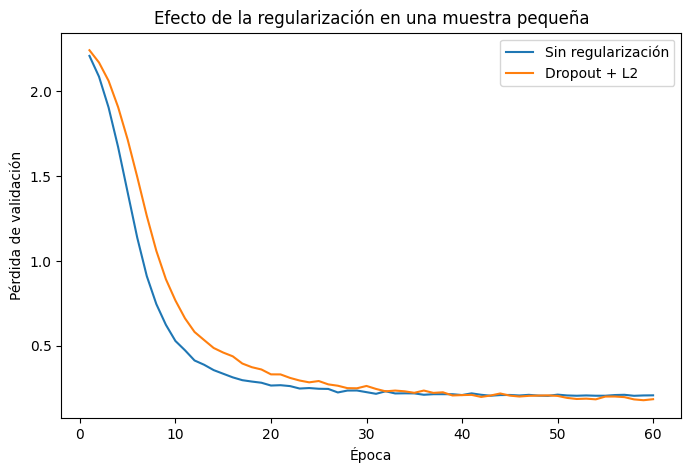

In [30]:
plt.figure(figsize=(8, 5))
for nombre, historia in historias_reg.items():
    plt.plot(historia["epoch"], historia["val_loss"], label=nombre)
plt.xlabel("Época")
plt.ylabel("Pérdida de validación")
plt.title("Efecto de la regularización en una muestra pequeña")
plt.legend()
plt.show()

### Parada temprana

La mejor época no tiene por qué ser la última. Una estrategia práctica es guardar el estado con menor pérdida de validación y detener el entrenamiento cuando no haya mejora durante cierto número de épocas (`patience`). En las funciones de este notebook, esta lógica se implementa en `entrenar_clasificador`.

La parada temprana es una forma de regularización: limita cuánto se adapta la red al ruido de entrenamiento.

### 10.7.4 Ajuste de la red

Los hiperparámetros principales incluyen:

- número de capas ocultas;
- unidades por capa;
- función de activación;
- tasa de aprendizaje;
- tamaño de mini-lote;
- número máximo de épocas;
- intensidad L1/L2;
- tasa de *dropout*;
- transformaciones de aumento de datos.

Deben elegirse usando validación o validación cruzada, nunca mirando repetidamente el conjunto de prueba. La prueba se reserva para una evaluación final.

A modo de ejemplo, evaluamos cuatro configuraciones pequeñas sobre el mismo conjunto de validación.

In [31]:
configuraciones = [
    {"hidden": (64,), "dropout": 0.0, "lr": 1e-3, "weight_decay": 0.0},
    {"hidden": (128,), "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-4},
    {"hidden": (128, 64), "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-4},
    {"hidden": (128, 64), "dropout": 0.35, "lr": 5e-4, "weight_decay": 1e-3},
]

filas_tuning = []
for i, cfg in enumerate(configuraciones, start=1):
    torch.manual_seed(SEED)
    modelo = ClasificadorDenso(
        hidden_sizes=cfg["hidden"],
        dropout=cfg["dropout"],
    )
    historia = entrenar_clasificador(
        modelo,
        train_loader,
        val_loader,
        max_epochs=18,
        learning_rate=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        patience=4,
    )
    resultado_val = evaluar_clasificador(modelo, val_loader)
    filas_tuning.append({
        "Configuración": i,
        "Capas": str(cfg["hidden"]),
        "Dropout": cfg["dropout"],
        "LR": cfg["lr"],
        "L2": cfg["weight_decay"],
        "Parámetros": contar_parametros(modelo),
        "Épocas": len(historia),
        "Exactitud validación": resultado_val["accuracy"],
        "Pérdida validación": resultado_val["loss"],
    })

resultados_tuning = pd.DataFrame(filas_tuning).sort_values("Pérdida validación")
resultados_tuning.round(4)

,Configuración,Capas,Dropout,LR,L2,Parámetros,Épocas,Exactitud validación,Pérdida validación
2,3,"(128, 64)",0.20,0.0010,0.0001,17226,18,0.9653,0.1266
1,2,"(128,)",0.20,0.0010,0.0001,9610,18,0.9618,0.2003
0,1,"(64,)",0.00,0.0010,0.0000,4810,18,0.9618,0.2780
3,4,"(128, 64)",0.35,0.0005,0.0010,17226,18,0.9479,0.3214


### Flujo de trabajo recomendado

1. **Construir una línea base** sencilla.
2. **Separar** entrenamiento, validación y prueba.
3. **Escalar** variables continuas cuando corresponda.
4. Empezar con una arquitectura pequeña y una tasa de aprendizaje razonable.
5. Observar conjuntamente pérdida y métrica en entrenamiento y validación.
6. Añadir capacidad solo si hay subajuste.
7. Añadir regularización si aparece una brecha creciente entre entrenamiento y validación.
8. Registrar semillas, versiones, arquitectura e hiperparámetros.
9. Evaluar una sola vez en prueba después de cerrar las decisiones.
10. Comparar el beneficio con el costo computacional y la pérdida de interpretabilidad.

## Resumen

- Una red de una capa oculta construye características no lineales y combina esas activaciones en la salida.
- Varias capas componen transformaciones y permiten representaciones jerárquicas.
- Softmax y entropía cruzada son la combinación estándar para clasificación multiclase.
- Las CNN aprovechan localidad, pesos compartidos y estructura espacial.
- Convolución, ReLU y *pooling* forman los bloques básicos de muchas CNN.
- El aumento de datos y la transferencia de aprendizaje son herramientas centrales cuando los datos etiquetados son limitados.
- El aprendizaje profundo es especialmente potente con grandes conjuntos y datos no estructurados, pero no domina necesariamente en muestras tabulares pequeñas.
- Retropropagación calcula gradientes; SGD o Adam actualizan los parámetros.
- L2, *dropout*, aumento de datos y parada temprana controlan el sobreajuste.
- La selección de arquitectura e hiperparámetros debe basarse en validación, no en el conjunto de prueba.

## Ejercicios propuestos

1. En `make_moons`, compara 2, 4, 16, 64 y 256 unidades ocultas. Registra exactitud de entrenamiento y prueba.
2. Sustituye ReLU por `tanh` en el ejemplo anterior. Describe el cambio de frontera y convergencia.
3. En `ClasificadorDenso`, elimina una capa y luego añade una tercera. Compara número de parámetros y desempeño.
4. Modifica el tamaño de mini-lote entre 16, 64 y 256. ¿Cómo cambia el número de actualizaciones por época y el tiempo de ajuste?
5. Entrena la CNN usando `loader_aumentado`. Compara la mejor pérdida de validación con la CNN sin aumento.
6. Cambia el *pooling* máximo por `AvgPool2d`. Explica qué información resume cada operación.
7. Prueba tasas de *dropout* 0, 0.1, 0.3, 0.5 y 0.7 en la muestra pequeña de 220 imágenes.
8. Descongela la segunda convolución del clasificador de paridad y realiza ajuste fino con una tasa de aprendizaje menor.
9. En el conjunto `diabetes`, repite la comparación con validación cruzada repetida. Reporta media y desviación estándar.
10. Implementa descenso por gradiente para una regresión lineal y verifica que `autograd` produce el mismo gradiente que la fórmula analítica.

## Referencias

- James, G., Witten, D., Hastie, T., Tibshirani, R. y Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Capítulo 10, especialmente secciones 10.1, 10.2, 10.3, 10.6 y 10.7.
- PyTorch. [Tutoriales oficiales](https://pytorch.org/tutorials/).
- scikit-learn. [Documentación de redes neuronales supervisadas](https://scikit-learn.org/stable/modules/neural_networks_supervised.html).
- Estilo pedagógico inspirado en las notas [Machine Learning con Python](https://vmoprojs.github.io/MLPython/).

> Los resultados numéricos pueden variar ligeramente entre versiones de las bibliotecas o dispositivos, incluso con semillas fijadas.